# Spatio-Temporal Crime Pattern Analysis in the UK
## Model Notebook 1 — Crime Category Classification
### XGBoost · LightGBM

---

| Item | Detail |
|---|---|
| **Task** | Multi-class supervised classification of crime type |
| **Target variable** | `Crime type` (14 categories) |
| **Primary models** |· XGBoost · LightGBM |

> **Why these models?**  
> Tree-based ensembles handle the combination of categorical, ordinal, and continuous features that characterise this dataset without requiring feature scaling. They naturally capture non-linear interactions (e.g. *season × location*), are robust to the class-imbalance inherent in crime data, and produce feature-importance scores that are directly interpretable for a dissertation methodology chapter. XGBoost and LightGBM add gradient-boosting with built-in regularisation
---

## 1 · Environment Setup

In [ ]:
# ── Install any packages not shipped with Colab ──────────────────────────────
!pip -q install xgboost lightgbm shap imbalanced-learn optuna
# Install ML libraries: XGBoost (boosting), LightGBM (fast GBM), SHAP (explainability), imbalanced-learn (handling class imbalance), Optuna (hyperparameter tuning)

In [ ]:
import os, gc, warnings, time  # os: file handling, gc: garbage collection, warnings: control warnings, time: timing execution
from pathlib import Path  # Object-oriented filesystem paths

import numpy as np  # Numerical computations
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting library
import matplotlib.ticker as mticker  # Axis tick formatting tools
import seaborn as sns  # Statistical visualization built on matplotlib
import plotly.express as px  # High-level interactive visualizations

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate  # Data splitting & cross-validation tools
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder  # Encoding categorical variables
from sklearn.metrics import (  # Model evaluation metrics
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, top_k_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier  # Tree-based ensemble classifier
from sklearn.pipeline import Pipeline  # Standard ML pipeline utility
from sklearn.inspection import permutation_importance  # Feature importance estimation

import xgboost as xgb  # Extreme Gradient Boosting model
import lightgbm as lgb  # Light Gradient Boosting Machine model
import shap  # Model explainability tool (SHAP values)
import optuna  # Hyperparameter optimization framework

from imblearn.over_sampling import SMOTENC  # Oversampling for categorical + numerical data
from imblearn.under_sampling import RandomUnderSampler  # Undersampling technique
from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline supporting imbalanced-learn methods

warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
pd.set_option('display.max_columns', 80)  # Show up to 80 columns in pandas display
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')  # Format floats to 4 decimal places
sns.set_theme(style='whitegrid', palette='muted')  # Set seaborn visualization theme

SEED = 42  # Fix random seed for reproducibility
np.random.seed(SEED)  # Apply seed to NumPy randomness

print('All libraries loaded successfully.')  # Confirmation message after imports

All libraries loaded successfully.


## 2 ·  Load Cleaned Data

In [1]:
import os  # Provides functions for interacting with the operating system (file paths, directories)

# Read-only input path
DATA_DIR = '/kaggle/input/datasets/uk-police-dataset'  # Kaggle dataset directory (input, read-only)
CLEANED_PATH = os.path.join(DATA_DIR, 'uk_police_full_cleaned.parquet')  # Full path to cleaned dataset file

# Writable output path
OUTPUT_DIR = '/kaggle/working/model1_outputs'  # Directory where outputs (models, plots, files) will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)  # Create output directory if it doesn't exist

print('Expected cleaned data path:', CLEANED_PATH)  # Display dataset path being used
print('Model outputs will be saved to:', OUTPUT_DIR)  # Display output directory location

Expected cleaned data path: /kaggle/input/datasets/uk-police-dataset/uk_police_full_cleaned.parquet
Model outputs will be saved to: /kaggle/working/model1_outputs


In [ ]:
df_raw = pd.read_parquet(CLEANED_PATH)  # Load cleaned dataset from parquet file into a DataFrame
print('Loaded shape:', df_raw.shape)  # Print number of rows and columns in dataset
df_raw.head(3)  # Display first 3 rows for quick inspection

Loaded shape: (17013276, 19)


,Context,Crime ID,Crime type,Falls within,LSOA code,LSOA name,Last outcome category,Latitude,Location,Longitude,Month,Reported by,source_file,source_folder,Year,Month_Num,Month_Name,Quarter,Season
0,NaN,44949804e10105361f806c22620b183ed7b4337bc53c62...,Vehicle crime,Avon and Somerset Constabulary,E01007420,Barnsley 016C,Status update unavailable,53.5504,On or near Hawthorn Grove,-1.5637,2023-02-01,Avon and Somerset Constabulary,2023-02-avon-and-somerset-street.csv,2023-02,2023,2,February,1,Winter
1,NaN,None,Anti-social behaviour,Avon and Somerset Constabulary,E01014399,Bath and North East Somerset 001A,NaN,51.4250,On or near Maximus Gardens,-2.4911,2023-02-01,Avon and Somerset Constabulary,2023-02-avon-and-somerset-street.csv,2023-02,2023,2,February,1,Winter
2,NaN,None,Anti-social behaviour,Avon and Somerset Constabulary,E01014399,Bath and North East Somerset 001A,NaN,51.4097,On or near Barnard Walk,-2.5093,2023-02-01,Avon and Somerset Constabulary,2023-02-avon-and-somerset-street.csv,2023-02,2023,2,February,1,Winter


## 3 · Feature Engineering

We construct four groups of predictors:

| Group | Features | Rationale |
|---|---|---|
| **Temporal** | Year, Month_Num, Quarter, Season, DayOfWeek proxy | Crime frequency is strongly seasonal |
| **Spatial** | Longitude, Latitude, lon_bin, lat_bin, region | Geographic clustering drives crime type |
| **Administrative** | Force area, LSOA code | Policing policy and demographic proxy |
| **Derived** | lon×lat grid cell, temporal interaction | Capture spatio-temporal joint effects |


In [ ]:
df = df_raw.copy()  # Create a working copy to preserve original dataset

# ── Temporal features ────────────────────────────────────────────────────────
if 'Month' in df.columns:  # Check if Month column exists
    df['Month'] = pd.to_datetime(df['Month'], errors='coerce')  # Convert to datetime format
    df['Year']      = df['Month'].dt.year  # Extract year
    df['Month_Num'] = df['Month'].dt.month  # Extract numeric month (1–12)
    df['Quarter']   = df['Month'].dt.quarter  # Extract quarter (1–4)

    season_map = {  # Map months to seasons
        12:'Winter',1:'Winter',2:'Winter',
        3:'Spring',4:'Spring',5:'Spring',
        6:'Summer',7:'Summer',8:'Summer',
        9:'Autumn',10:'Autumn',11:'Autumn'
    }

    df['Season'] = df['Month_Num'].map(season_map)  # Assign seasonal category

# ── Spatial binning (0.05° ≈ 5 km grid cells) ───────────────────────────────
if {'Longitude','Latitude'}.issubset(df.columns):  # Ensure spatial columns exist
    df['lon_bin'] = (df['Longitude'] / 0.05).round(0).astype('Int32')  # Longitude grid binning
    df['lat_bin'] = (df['Latitude']  / 0.05).round(0).astype('Int32')  # Latitude grid binning
    df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)  # Create spatial grid ID

# ── Drop columns not needed for modelling ───────────────────────────────────
DROP_COLS = ['Crime ID','Location','LSOA code','LSOA name',  # Irrelevant identifiers
             'Month','Month_Name','Last outcome category',  # Raw/processed duplicates or target leakage risk
             'Reported by','source_file']  # Metadata / source tracking columns

df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)  # Drop only existing columns

print('Feature-engineered shape:', df.shape)  # Show final dataset shape after feature engineering
print('Columns retained:', df.columns.tolist())  # Display final feature set

Feature-engineered shape: (17013276, 13)
Columns retained: ['Context', 'Crime type', 'Falls within', 'Latitude', 'Longitude', 'source_folder', 'Year', 'Month_Num', 'Quarter', 'Season', 'lon_bin', 'lat_bin', 'grid_cell']


In [ ]:
# ── Target variable ──────────────────────────────────────────────────────────
TARGET = 'Crime type'  # Define prediction target column

# Drop rows with missing target
df = df.dropna(subset=[TARGET]).reset_index(drop=True)  # Remove rows where target is missing and reset index

print('Rows after dropping missing target:', len(df))  # Print dataset size after cleaning

print('\nClass distribution (top 15):')  # Header for class distribution output
dist = df[TARGET].value_counts(normalize=True).head(15) * 100  # Compute percentage distribution of top 15 classes

display(dist.to_frame('% share').round(2))  # Display formatted distribution as DataFrame

Rows after dropping missing target: 17013276

Class distribution (top 15):


,% share
Crime type,
Violence and sexual offences,36.4200
Anti-social behaviour,11.5500
Shoplifting,8.1900
Criminal damage and arson,7.9600
Other theft,7.5700
Public order,7.4300
Vehicle crime,5.8700
Burglary,4.1400
Drugs,3.2900


## 4 · Preprocessing — Encoding and Train/Test Split

In [ ]:
# ── Label-encode the target ──────────────────────────────────────────────────
le_target = LabelEncoder()  # Initialize label encoder for converting categorical target into numeric labels
df['label'] = le_target.fit_transform(df[TARGET])  # Fit encoder on target and transform into integer labels

n_classes = len(le_target.classes_)  # Count total number of unique crime type classes
print(f'Number of crime-type classes: {n_classes}')  # Print number of classes
print('Classes:', le_target.classes_.tolist())  # Print list of all crime categories

Number of crime-type classes: 14
Classes: ['Anti-social behaviour', 'Bicycle theft', 'Burglary', 'Criminal damage and arson', 'Drugs', 'Other crime', 'Other theft', 'Possession of weapons', 'Public order', 'Robbery', 'Shoplifting', 'Theft from the person', 'Vehicle crime', 'Violence and sexual offences']


In [ ]:
# ── Ordinal-encode all object/category columns ───────────────────────────────
FEATURE_COLS = [c for c in df.columns if c not in [TARGET, 'label']]  # Select all feature columns except target and label

cat_cols = df[FEATURE_COLS].select_dtypes(include=['object','category']).columns.tolist()  # Identify categorical columns
num_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()  # Identify numerical columns

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)  # Encoder for categorical variables with safe handling for unseen values
df[cat_cols] = oe.fit_transform(df[cat_cols].astype(str))  # Convert categorical values into numeric codes

# Fill any remaining NaN with median (numeric) or -1 (categorical)
for c in num_cols:  # Loop through numeric columns
    df[c] = df[c].fillna(df[c].median())  # Replace missing numeric values with median

for c in cat_cols:  # Loop through categorical columns
    df[c] = df[c].fillna(-1)  # Replace missing categorical values with -1

X = df[FEATURE_COLS].values.astype(np.float32)  # Convert features into NumPy array (float32 for efficiency)
y = df['label'].values  # Extract target labels as NumPy array

print('Feature matrix shape:', X.shape)  # Print shape of feature matrix
print('Feature columns:', FEATURE_COLS)  # Print list of feature columns used

Feature matrix shape: (17013276, 12)
Feature columns: ['Context', 'Falls within', 'Latitude', 'Longitude', 'source_folder', 'Year', 'Month_Num', 'Quarter', 'Season', 'lon_bin', 'lat_bin', 'grid_cell']


In [ ]:
# ── Stratified 80/20 split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED  # 80% training, 20% testing with class balance preserved
)

print(f'Train size : {X_train.shape[0]:,}')  # Print number of training samples
print(f'Test  size : {X_test.shape[0]:,}')  # Print number of testing samples

Train size : 13,610,620
Test  size : 3,402,656


In [ ]:
# ── Class-weight dictionary (for Random Forest) ──────────────────────────────
from sklearn.utils.class_weight import compute_class_weight  # Utility to compute balanced class weights

cw = compute_class_weight(  # Compute weights to handle class imbalance
    'balanced',
    classes=np.unique(y_train),  # Unique classes in training data
    y=y_train  # Training labels used to compute frequency-based weights
)

class_weight_dict = dict(enumerate(cw))  # Convert computed weights into dictionary format (class index → weight)

print('Sample class weights (first 5):', {  # Print preview of class weights
    k: round(v,3) for k,v in list(class_weight_dict.items())[:5]  # Round and show only first 5 entries
})

Sample class weights (first 5): {0: np.float64(0.618), 1: np.float64(7.146), 2: np.float64(1.726), 3: np.float64(0.898), 4: np.float64(2.17)}


## 6 · Model 2 — XGBoost Classifier

**Why XGBoost?**  
XGBoost is a gradient-boosted tree framework that sequentially corrects the errors of previous trees using second-order Taylor expansion of the loss function. It adds:
- L1/L2 regularisation to prevent overfitting on the large feature set  
- Built-in sparsity awareness (handles encoded missing values natively)  
- `scale_pos_weight` / `sample_weight` for class imbalance  
- Parallelised histogram-based split-finding for speed on large datasets  
- GPU support on Colab (`tree_method='hist'`, `device='cuda'`)


In [ ]:
# ── Scale pos weight for multi-class imbalance (via sample_weight) ────────────
from sklearn.utils import class_weight as skw  # Import utility for computing sample weights
sample_weights_train = skw.compute_sample_weight('balanced', y_train)  # Assign higher weights to underrepresented classes

XGB_PARAMS = {  # Hyperparameter configuration for XGBoost model
    'n_estimators'      : 500,  # Number of boosting rounds (trees)
    'max_depth'         : 8,  # Maximum depth of each tree
    'learning_rate'     : 0.05,  # Step size shrinkage to prevent overfitting
    'subsample'         : 0.8,  # Fraction of samples used per tree
    'colsample_bytree'  : 0.8,  # Fraction of features used per tree
    'reg_alpha'         : 0.1,  # L1 regularization term
    'reg_lambda'        : 1.0,  # L2 regularization term
    'num_class'         : n_classes,  # Number of output classes
    'objective'         : 'multi:softprob',  # Multi-class classification with probability outputs
    'eval_metric'       : 'mlogloss',  # Log loss for multi-class evaluation
    'tree_method'       : 'hist',  # Histogram-based training for efficiency
    'device'            : 'cuda',  # Use GPU acceleration (if available)
    'use_label_encoder' : False,  # Disable legacy label encoder
    'random_state'      : SEED,  # Reproducibility seed
    'verbosity'         : 0,  # Suppress training logs
    'n_jobs'            : -1,  # Use all CPU cores
    'early_stopping_rounds': 30,  # Stop training if no improvement for 30 rounds
}

print('Training XGBoost …')  # Indicate training start
t0 = time.time()  # Start timer

xgb_model = xgb.XGBClassifier(**XGB_PARAMS)  # Initialize XGBoost classifier with defined parameters
xgb_model.fit(
    X_train, y_train,  # Training data and labels
    sample_weight=sample_weights_train,  # Handle class imbalance using sample weights
    eval_set=[(X_test, y_test)],  # Validation set for monitoring performance
    verbose=50  # Print progress every 50 iterations
)

xgb_train_time = time.time() - t0  # Compute total training time
print(f'Training complete in {xgb_train_time:.1f}s')  # Display training duration

Training XGBoost …
[0]	validation_0-mlogloss:2.63372
[50]	validation_0-mlogloss:2.54523
[100]	validation_0-mlogloss:2.52889
[150]	validation_0-mlogloss:2.52200
[200]	validation_0-mlogloss:2.51734
[250]	validation_0-mlogloss:2.51367
[300]	validation_0-mlogloss:2.51041
[350]	validation_0-mlogloss:2.50732
[400]	validation_0-mlogloss:2.50471
[450]	validation_0-mlogloss:2.50243
[499]	validation_0-mlogloss:2.50023
Training complete in 452.4s


In [ ]:
# ── Predictions & metrics ─────────────────────────────────────────────────────
y_pred_xgb  = xgb_model.predict(X_test)  # Predicted class labels from XGBoost
y_prob_xgb  = xgb_model.predict_proba(X_test)  # Predicted class probabilities for all classes

xgb_acc     = accuracy_score(y_test, y_pred_xgb)  # Overall accuracy
xgb_bal_acc = balanced_accuracy_score(y_test, y_pred_xgb)  # Balanced accuracy (handles class imbalance)
xgb_macro_f1 = f1_score(y_test, y_pred_xgb, average='macro')  # Macro F1 (treats all classes equally)
xgb_weighted_f1 = f1_score(y_test, y_pred_xgb, average='weighted')  # Weighted F1 (accounts for class frequency)

print('── XGBoost Test Metrics ─────────────────────────────────')  # Header for evaluation results
print(f'  Accuracy          : {xgb_acc:.4f}')  # Print accuracy
print(f'  Balanced Accuracy : {xgb_bal_acc:.4f}')  # Print balanced accuracy
print(f'  Macro F1          : {xgb_macro_f1:.4f}')  # Print macro F1 score
print(f'  Weighted F1       : {xgb_weighted_f1:.4f}')  # Print weighted F1 score
print(f'  Top-3 Accuracy    : {top_k_accuracy_score(y_test, y_prob_xgb, k=3):.4f}')  # Top-3 accuracy metric

── XGBoost Test Metrics ─────────────────────────────────
  Accuracy          : 0.1178
  Balanced Accuracy : 0.1886
  Macro F1          : 0.1133
  Weighted F1       : 0.1123
  Top-3 Accuracy    : 0.3463


In [ ]:
print(classification_report(
    y_test, y_pred_xgb,  # True labels vs XGBoost predicted labels
    target_names=le_target.classes_,  # Original class names for readable output
    digits=4  # Number of decimal places in the report
))

                              precision    recall  f1-score   support

       Anti-social behaviour     0.2078    0.1949    0.2011    393148
               Bicycle theft     0.0328    0.3231    0.0595     34013
                    Burglary     0.0835    0.0891    0.0862    140823
   Criminal damage and arson     0.1282    0.0704    0.0909    270744
                       Drugs     0.0838    0.1594    0.1098    112005
                 Other crime     0.0438    0.2122    0.0726     73612
                 Other theft     0.2304    0.0214    0.0391    257541
       Possession of weapons     0.0190    0.1981    0.0348     33027
                Public order     0.1132    0.1490    0.1286    252947
                     Robbery     0.0331    0.1429    0.0537     45340
                 Shoplifting     0.2384    0.2168    0.2271    278752
       Theft from the person     0.1605    0.6253    0.2554     71483
               Vehicle crime     0.1299    0.1997    0.1574    199880
Violence and sexual

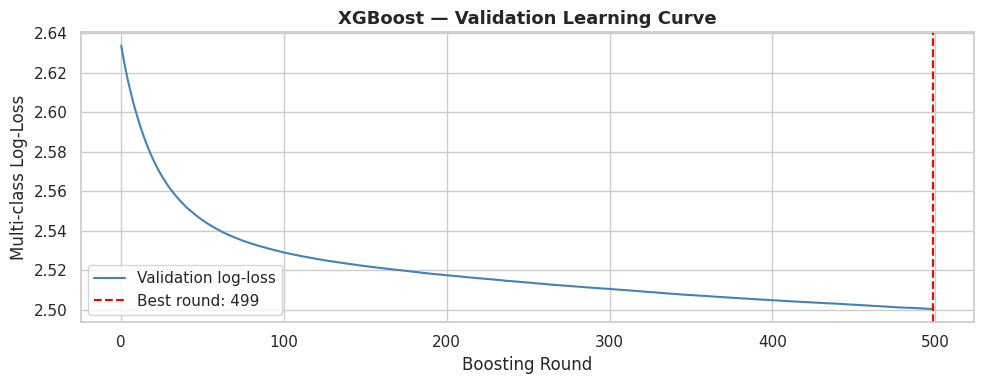

In [ ]:
# ── Learning curves (log-loss vs. rounds) ─────────────────────────────────────
results = xgb_model.evals_result()  # Extract evaluation results from XGBoost training history

if 'validation_0' in results and 'mlogloss' in results['validation_0']:  # Check if validation log-loss exists
    val_loss = results['validation_0']['mlogloss']  # Get validation log-loss per boosting round

    fig, ax = plt.subplots(figsize=(10, 4))  # Create figure for learning curve

    ax.plot(val_loss, label='Validation log-loss', color='steelblue')  # Plot validation loss curve

    best_round = np.argmin(val_loss)  # Find round with minimum log-loss (best performance)
    ax.axvline(best_round, color='red', linestyle='--', label=f'Best round: {best_round}')  # Mark best iteration

    ax.set_xlabel('Boosting Round')  # X-axis label
    ax.set_ylabel('Multi-class Log-Loss')  # Y-axis label
    ax.set_title('XGBoost — Validation Learning Curve', fontsize=13, fontweight='bold')  # Plot title

    ax.legend()  # Show legend for curves

    plt.tight_layout()  # Adjust layout for better spacing
    plt.savefig(os.path.join(OUTPUT_DIR, 'xgb_learning_curve.png'), dpi=150, bbox_inches='tight')  # Save figure
    plt.show()  # Display plot

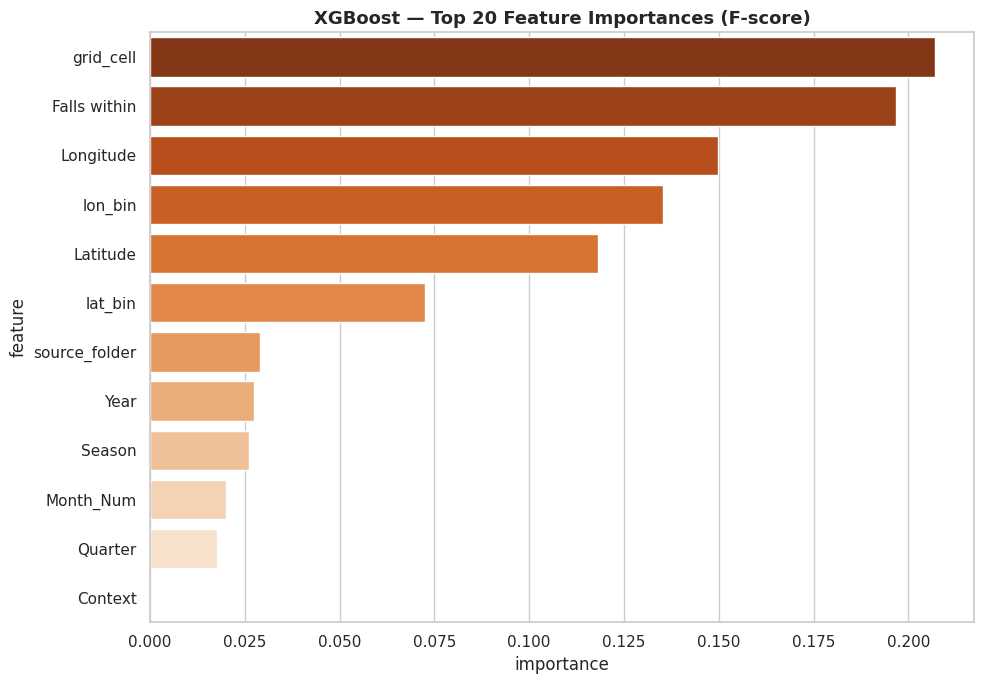

In [ ]:
# ── XGBoost feature importance ────────────────────────────────────────────────
xgb_imp = pd.DataFrame({
    'feature'   : FEATURE_COLS,  # Feature names used in training
    'importance': xgb_model.feature_importances_  # Importance scores from trained XGBoost model
}).sort_values('importance', ascending=False).head(20)  # Sort by importance and keep top 20 features

fig, ax = plt.subplots(figsize=(10, 7))  # Create figure for horizontal bar plot

sns.barplot(
    data=xgb_imp,  # Data containing top features
    x='importance',  # X-axis = importance score
    y='feature',  # Y-axis = feature names
    palette='Oranges_r',  # Color palette (reversed orange scale)
    ax=ax  # Plot on specified axis
)

ax.set_title('XGBoost — Top 20 Feature Importances (F-score)', fontsize=13, fontweight='bold')  # Plot title

plt.tight_layout()  # Adjust layout to prevent overlap
plt.savefig(os.path.join(OUTPUT_DIR, 'xgb_feature_importance.png'), dpi=150, bbox_inches='tight')  # Save figure
plt.show()  # Display plot

## 7 · Model 3 — LightGBM Classifier

**Why LightGBM?**  
LightGBM extends gradient boosting with two key innovations:  
1. **Gradient-based One-Side Sampling (GOSS)** — retains high-gradient instances and random-samples low-gradient ones, reducing training data size without information loss.  
2. **Exclusive Feature Bundling (EFB)** — bundles mutually exclusive sparse features, reducing feature count and memory.  

On large UK crime datasets (millions of rows, many one-hot-like encoded columns) LightGBM is typically 3–10× faster than XGBoost at equivalent accuracy, making it the preferred production model for operational police analytics systems.


In [ ]:
LGBM_PARAMS = {  # Hyperparameters for LightGBM multiclass classifier
    'n_estimators'     : 1000,  # Maximum number of boosting iterations (trees)
    'num_leaves'       : 127,  # Maximum number of leaves per tree (controls complexity)
    'max_depth'        : -1,  # No restriction on tree depth
    'learning_rate'    : 0.05,  # Step size shrinkage to slow learning and improve generalization
    'subsample'        : 0.8,  # Fraction of rows used per tree (bagging)
    'colsample_bytree' : 0.8,  # Fraction of features used per tree
    'reg_alpha'        : 0.1,  # L1 regularization (sparsity control)
    'reg_lambda'       : 1.0,  # L2 regularization (smoothness control)
    'min_child_samples': 20,  # Minimum data points required in a leaf
    'class_weight'     : 'balanced',  # Handle class imbalance automatically
    'objective'        : 'multiclass',  # Multiclass classification objective
    'metric'           : 'multi_logloss',  # Loss function for evaluation
    'num_class'        : n_classes,  # Number of output classes
    'device'           : 'gpu',  # Use GPU for faster training (fallback: cpu)
    'random_state'     : SEED,  # Reproducibility seed
    'n_jobs'           : -1,  # Use all CPU cores
    'verbose'          : -1,  # Suppress internal LightGBM logs
}

callbacks = [  # Training callbacks for monitoring and early stopping
    lgb.early_stopping(stopping_rounds=40, verbose=True),  # Stop if no improvement for 40 rounds
    lgb.log_evaluation(period=100)  # Print evaluation metrics every 100 iterations
]

print('Training LightGBM …')  # Indicate training start
t0 = time.time()  # Start timer

lgbm_model = lgb.LGBMClassifier(**LGBM_PARAMS)  # Initialize LightGBM model with parameters

lgbm_model.fit(
    X_train, y_train,  # Training data
    eval_set=[(X_test, y_test)],  # Validation set for monitoring performance
    callbacks=callbacks  # Apply early stopping and logging callbacks
)

lgbm_train_time = time.time() - t0  # Compute total training time
print(f'Training complete in {lgbm_train_time:.1f}s')  # Display training duration

Training LightGBM …


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 40 rounds
[100]	valid_0's multi_logloss: 2.51305
[200]	valid_0's multi_logloss: 2.50083
[300]	valid_0's multi_logloss: 2.49318
[400]	valid_0's multi_logloss: 2.48713
[500]	valid_0's multi_logloss: 2.48248
[600]	valid_0's multi_logloss: 2.47861
[700]	valid_0's multi_logloss: 2.47525
[800]	valid_0's multi_logloss: 2.47241
[900]	valid_0's multi_logloss: 2.46984
[1000]	valid_0's multi_logloss: 2.46751
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 2.46751
Training complete in 4946.1s


In [ ]:
y_pred_lgbm  = lgbm_model.predict(X_test)  # Predicted class labels from LightGBM model
y_prob_lgbm  = lgbm_model.predict_proba(X_test)  # Predicted probabilities for all classes

lgbm_acc       = accuracy_score(y_test, y_pred_lgbm)  # Overall accuracy
lgbm_bal_acc   = balanced_accuracy_score(y_test, y_pred_lgbm)  # Balanced accuracy (handles class imbalance)
lgbm_macro_f1  = f1_score(y_test, y_pred_lgbm, average='macro')  # Macro F1 score (treats all classes equally)
lgbm_wt_f1     = f1_score(y_test, y_pred_lgbm, average='weighted')  # Weighted F1 score (accounts for class distribution)

print('── LightGBM Test Metrics ────────────────────────────────')  # Header for results
print(f'  Accuracy          : {lgbm_acc:.4f}')  # Print accuracy
print(f'  Balanced Accuracy : {lgbm_bal_acc:.4f}')  # Print balanced accuracy
print(f'  Macro F1          : {lgbm_macro_f1:.4f}')  # Print macro F1
print(f'  Weighted F1       : {lgbm_wt_f1:.4f}')  # Print weighted F1
print(f'  Top-3 Accuracy    : {top_k_accuracy_score(y_test, y_prob_lgbm, k=3):.4f}')  # Top-3 accuracy metric

── LightGBM Test Metrics ────────────────────────────────
  Accuracy          : 0.1378
  Balanced Accuracy : 0.2031
  Macro F1          : 0.1274
  Weighted F1       : 0.1314
  Top-3 Accuracy    : 0.3683


In [ ]:
print(classification_report(
    y_test, y_pred_lgbm,  # True labels vs LightGBM predicted labels
    target_names=le_target.classes_,  # Original class names for readable output
    digits=4  # Number of decimal places in the classification report
))

                              precision    recall  f1-score   support

       Anti-social behaviour     0.2135    0.1900    0.2010    393148
               Bicycle theft     0.0352    0.3258    0.0636     34013
                    Burglary     0.0943    0.1101    0.1016    140823
   Criminal damage and arson     0.1353    0.0728    0.0947    270744
                       Drugs     0.0896    0.1796    0.1195    112005
                 Other crime     0.0475    0.2029    0.0770     73612
                 Other theft     0.2324    0.0379    0.0652    257541
       Possession of weapons     0.0203    0.1793    0.0364     33027
                Public order     0.1179    0.1263    0.1219    252947
                     Robbery     0.0350    0.1441    0.0563     45340
                 Shoplifting     0.2641    0.3835    0.3128    278752
       Theft from the person     0.1698    0.6171    0.2663     71483
               Vehicle crime     0.1429    0.2236    0.1744    199880
Violence and sexual

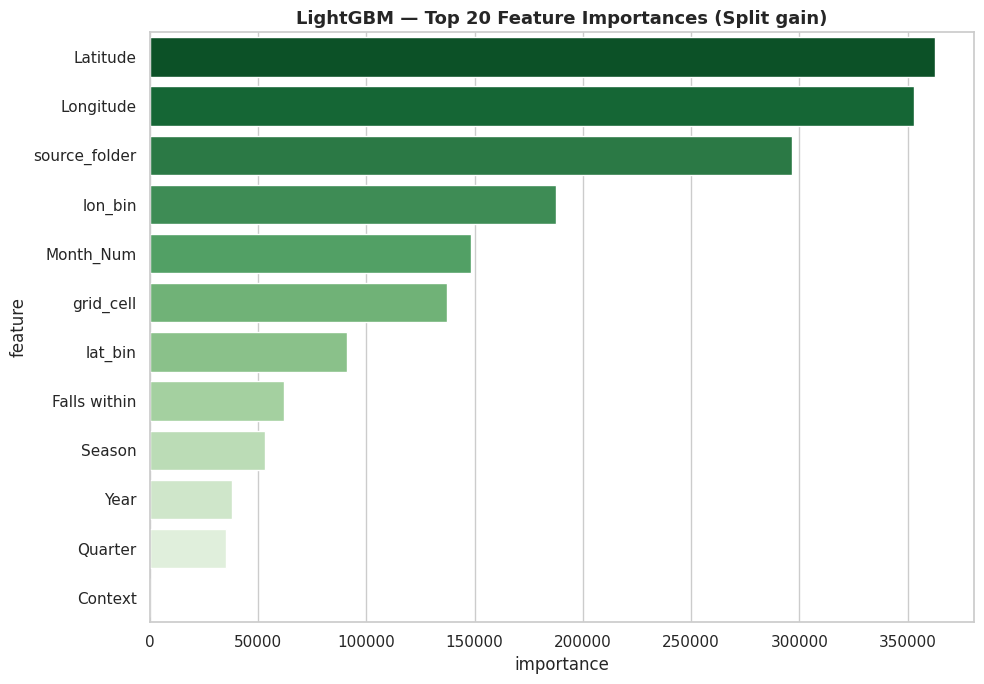

In [ ]:
# ── LightGBM feature importance ───────────────────────────────────────────────
lgbm_imp = pd.DataFrame({
    'feature'   : FEATURE_COLS,  # Feature names used in the model
    'importance': lgbm_model.feature_importances_  # Importance scores from trained LightGBM model
}).sort_values('importance', ascending=False).head(20)  # Sort features by importance and keep top 20

fig, ax = plt.subplots(figsize=(10, 7))  # Create figure for plotting

sns.barplot(
    data=lgbm_imp,  # Data containing top features
    x='importance',  # X-axis = importance score
    y='feature',  # Y-axis = feature names
    palette='Greens_r',  # Color palette (reversed green scale)
    ax=ax  # Plot on specified axis
)

ax.set_title('LightGBM — Top 20 Feature Importances (Split gain)', fontsize=13, fontweight='bold')  # Plot title

plt.tight_layout()  # Adjust layout to avoid overlap
plt.savefig(os.path.join(OUTPUT_DIR, 'lgbm_feature_importance.png'), dpi=150, bbox_inches='tight')  # Save figure
plt.show()  # Display plot